# Orbital Debris Visualizations

This notebook is visualization-only and reads from the SQLite database.

In [1]:
import numpy as np
import pandas as pd
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def run_query(sql):
    return pd.read_sql(sql, conn)

conn = sqlite3.connect('../data/clean/orbital_debris.db')
print('Connected to ../data/clean/orbital_debris.db')

# Set the Palette (High Contrast Neon)
sns.set_palette("plasma") 

# Set the Background (Deep Space Black)
plt.style.use('dark_background')

plt.rcParams.update({
    "grid.alpha": 0.2,            # Faint, non-intrusive grid
    "axes.facecolor": "black",    # No grey haze in plot area
    "figure.facecolor": "black",  # No grey haze in outer area
    "text.color": "white",        # High contrast text
    "axes.labelcolor": "white",   # Axis labels
    "xtick.color": "white",       # Ticks
    "ytick.color": "white",
    "legend.facecolor": "black",  # Legend background
    "legend.edgecolor": "white"   # Legend border
})

Connected to ../data/clean/orbital_debris.db


In [2]:
#########################################################################################################
# AI Assisted Function: fit_growth_regimes                                                              #
#                                                                                                       #
# What this does                                                                                        #
# - Splits yearly launch data into two regimes using a split year (2014).                      #
# - Fits a linear trend to the legacy period (pre-2014).                                                #
# - Fits an exponential trend to the modern period (post-2014) using a log-space linear fit.            #
# - Returns both fitted segments and key growth metrics.                                                #
#                                                                                                       #
# Why AI assistance was used                                                                            #
# - I understand the analysis goal (compare pre/post growth behavior),                                  #
#   but needed help structuring a clean reusable function for the two-regime fit workflow.              #
#                                                                                                       #
# AI (GitHub Copilot, GPT-5.3-Codex) helped draft the function structure and equations.                 #
#                                                                                                       #
#########################################################################################################
def fit_growth_regimes(df, split_year=2014):
    pre = df[df['launch_year'] <= split_year].copy()
    post = df[df['launch_year'] > split_year].copy()

    # Legacy regime: linear fit  y = m_pre * year + b_pre
    m_pre, b_pre = np.polyfit(pre['launch_year'], pre['objects_launched'], 1)
    pre['trend_linear'] = m_pre * pre['launch_year'] + b_pre

    # Modern regime: exponential fit  y = a_exp * exp(b_exp * year)
    # Implemented by fitting log(y) linearly in year, then transforming back
    post_fit = post[post['objects_launched'] > 0].copy()
    b_exp, a_log = np.polyfit(post_fit['launch_year'], np.log(post_fit['objects_launched']), 1)
    a_exp = np.exp(a_log)
    post['trend_exponential'] = a_exp * np.exp(b_exp * post['launch_year'])

    # Doubling time from exponential rate: ln(2)/b
    doubling_time = np.log(2) / b_exp
    return pre, post, m_pre, b_exp, doubling_time

##  Primary Question 1: Growth and Decoupling Baseline
The SQL-based fit places decoupling in the early-2010s window (about 2012–2014).   
We use 2014 as the reference year for consistency and interpretability.   

In [3]:
pq1 = '''
WITH yearly AS (
  SELECT
    launch_events.launch_year AS launch_year,
    COUNT(*) AS objects_launched,
    COUNT(DISTINCT launch_events.launch_id) AS launch_missions,
    SUM(
      CASE
        WHEN UPPER(COALESCE(satellites.object_type, '')) = 'PAYLOAD' THEN 1
        ELSE 0
      END
    ) AS payload_objects
  FROM satellites
  JOIN launch_events ON launch_events.launch_id = satellites.launch_id
  WHERE launch_events.launch_year IS NOT NULL
  GROUP BY launch_events.launch_year
)
SELECT
  launch_year,
  objects_launched,
  launch_missions,
  payload_objects,
  ROUND(100.0 * payload_objects / NULLIF(objects_launched, 0), 2) AS payload_share_pct,
  SUM(objects_launched) OVER (ORDER BY launch_year) AS cumulative_objects
FROM yearly
ORDER BY launch_year;
'''

launch_trend = run_query(pq1).sort_values('launch_year').reset_index(drop=True)
launch_trend['objects_3yr_avg'] = launch_trend['objects_launched'].rolling(3, min_periods=1).mean()
launch_trend['missions_3yr_avg'] = launch_trend['launch_missions'].rolling(3, min_periods=1).mean()

split_year = 2014
pre, post, m_pre, b_exp, doubling_time_years = fit_growth_regimes(launch_trend, split_year=split_year)

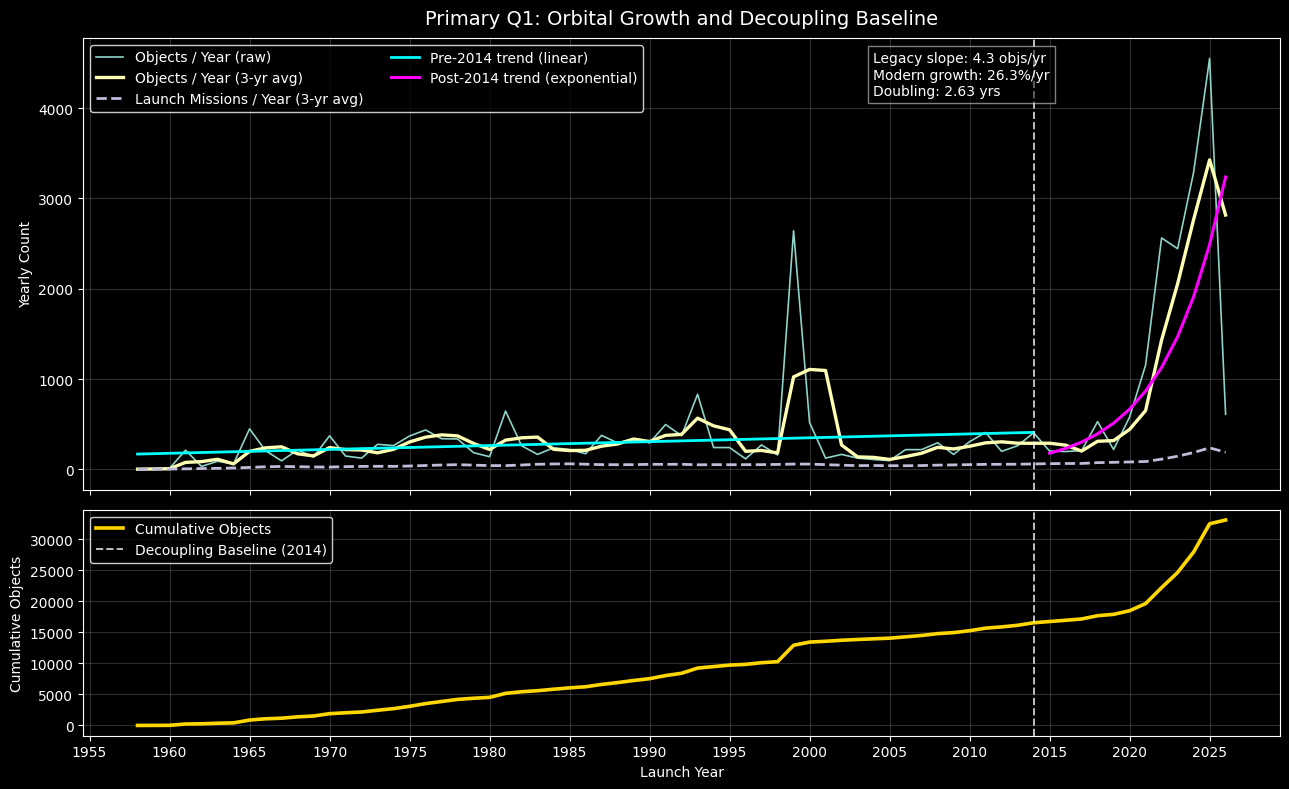

In [7]:
fig, (ax1, ax2) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(13, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 1]}
)

# Top graph lineplots.
sns.lineplot(
    data=launch_trend,
    x='launch_year',
    y='objects_launched',
    linewidth=1.2,
    ax=ax1,
    label='Objects / Year (raw)'
)
sns.lineplot(
    data=launch_trend,
    x='launch_year',
    y='objects_3yr_avg',
    linewidth=2.4,
    ax=ax1,
    label='Objects / Year (3-yr avg)'
)
sns.lineplot(
    data=launch_trend,
    x='launch_year',
    y='missions_3yr_avg',
    linewidth=2.0,
    linestyle='--',
    ax=ax1,
    label='Launch Missions / Year (3-yr avg)'
)

sns.lineplot(
    data=pre,
    x='launch_year',
    y='trend_linear',
    ax=ax1,
    color='cyan',
    linewidth=2.0,
    label='Pre-2014 trend (linear)'
)
sns.lineplot(
    data=post,
    x='launch_year',
    y='trend_exponential',
    ax=ax1,
    color='magenta',
    linewidth=2.2,
    label='Post-2014 trend (exponential)'
)

ax1.axvline(split_year, color='white', linestyle='--', alpha=0.75, linewidth=1.4)
ax1.text(
    0.66, 0.97,
    f'Legacy slope: {m_pre:,.1f} objs/yr\nModern growth: {b_exp:.1%}/yr\nDoubling: {doubling_time_years:.2f} yrs',
    transform=ax1.transAxes,
    va='top',
    ha='left',
    fontsize=10,
    bbox=dict(facecolor='black', edgecolor='white', alpha=0.5)
)

ax1.set_title('Primary Q1: Orbital Growth and Decoupling Baseline', fontsize=14, pad=10)
ax1.set_ylabel('Yearly Count')
ax1.grid(alpha=0.18)
ax1.legend(loc='upper left', ncol=2, frameon=True)

sns.lineplot(
    data=launch_trend,
    x='launch_year',
    y='cumulative_objects',
    color='gold',
    linewidth=2.6,
    ax=ax2,
    label='Cumulative Objects'
)
ax2.axvline(split_year, color='white', linestyle='--', alpha=0.75, linewidth=1.4, label='Decoupling Baseline (2014)')
ax2.set_xlabel('Launch Year')
ax2.set_ylabel('Cumulative Objects')
ax2.grid(alpha=0.18)
ax2.legend(loc='upper left', frameon=True)

ax2.xaxis.set_major_locator(ticker.MultipleLocator(5))

plt.tight_layout()
plt.savefig("../images/launch_trends_pq1.svg", bbox_inches="tight")
plt.show()

## **Tidy Up!**

In [5]:
# Close the connection.
# Release resources and ensure clean exit (old habits die hard).

conn.close()
print('Connection closed.')

Connection closed.
